<a href="https://colab.research.google.com/github/leonbenenati/projeto_avaliativo_modulo_1/blob/feature%2FFeature-Engineering/Projeto_Avaliativo_M%C3%B3dulo_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1: Análise Exploratória (EDA)

## 1.1 Análise inicial

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

In [ ]:
df = pd.read_csv("/content/manutencao_preditiva.csv")

In [ ]:
df

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604.0,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632.0,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645.0,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408.0,48.5,25,0,0,0,0,0,0


In [ ]:
def inspecionar_dados(df):
    """Exibe informações básicas do DataFrame."""
    print("\n=== INSPEÇÃO INICIAL DO DATASET ===")
    print(f"Shape: {df.shape}")
    print(f"\nTipos de dados:\n{df.dtypes}")
    print(f"\nValores nulos por coluna:\n{df.isnull().sum()}")
    print(f"\nEstatísticas descritivas:\n{df.describe()}")

In [ ]:
inspecionar_dados(df)



=== INSPEÇÃO INICIAL DO DATASET ===
Shape: (10000, 14)

Tipos de dados:
udi                          int64
id_produto                  object
tipo                        object
temperatura_ar_k           float64
temperatura_processo_k     float64
velocidade_rotacao_rpm     float64
torque_nm                  float64
desgaste_ferramenta_min      int64
falha_maquina                int64
falha_twf                    int64
falha_hdf                    int64
falha_pwf                    int64
falha_osf                    int64
falha_rnf                    int64
dtype: object

Valores nulos por coluna:
udi                          0
id_produto                   0
tipo                         0
temperatura_ar_k           500
temperatura_processo_k     500
velocidade_rotacao_rpm     500
torque_nm                  500
desgaste_ferramenta_min      0
falha_maquina                0
falha_twf                    0
falha_hdf                    0
falha_pwf                    0
falha_osf               

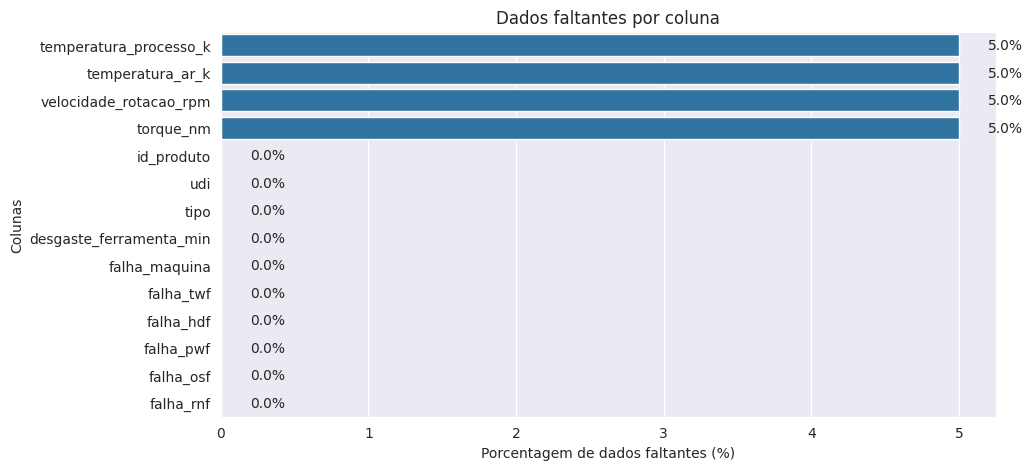

In [ ]:
missing_pct = df.isnull().mean() * 100

missing_pct = missing_pct.sort_values(ascending=False)
plt.figure(figsize=(10,5))

ax = sns.barplot(x=missing_pct.values, y=missing_pct.index)

for i, v in enumerate(missing_pct.values):
    ax.text(v + 0.2, i, f"{v:.1f}%", va='center')

plt.xlabel("Porcentagem de dados faltantes (%)")
plt.ylabel("Colunas")
plt.title("Dados faltantes por coluna")

plt.show()



*   O Dataframe tem 10000 linhas e 14 colunas
*   temperatura_ar_k, temperatura_processo_k, velocidade_rotacao_rpm e torque_nm tem 5% de dados faltantes




## 1.2 Análise falha_maquina

In [ ]:
df["falha_maquina"].value_counts(normalize=True) * 100

,proportion
falha_maquina,
0,96.61
1,3.39


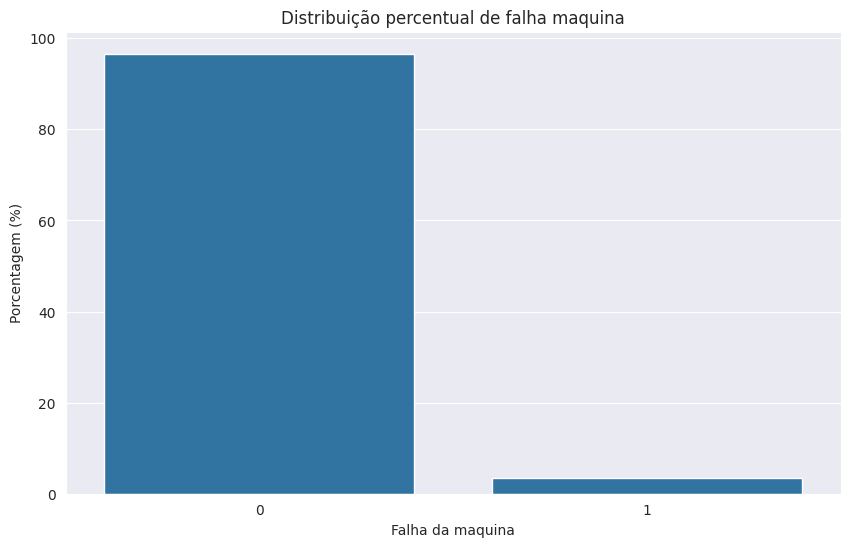

In [ ]:
plt.figure(figsize=(10,6))

percent = df['falha_maquina'].value_counts(normalize=True) * 100

sns.barplot(x=percent.index, y=percent.values)

plt.ylabel("Porcentagem (%)")
plt.xlabel("Falha da maquina")
plt.title("Distribuição percentual de falha maquina")

plt.show()



*   Classe alvo esta bem desbalanceada, 96,61% para 0 e 3,39% para 1



## 1.3 Análise tipo

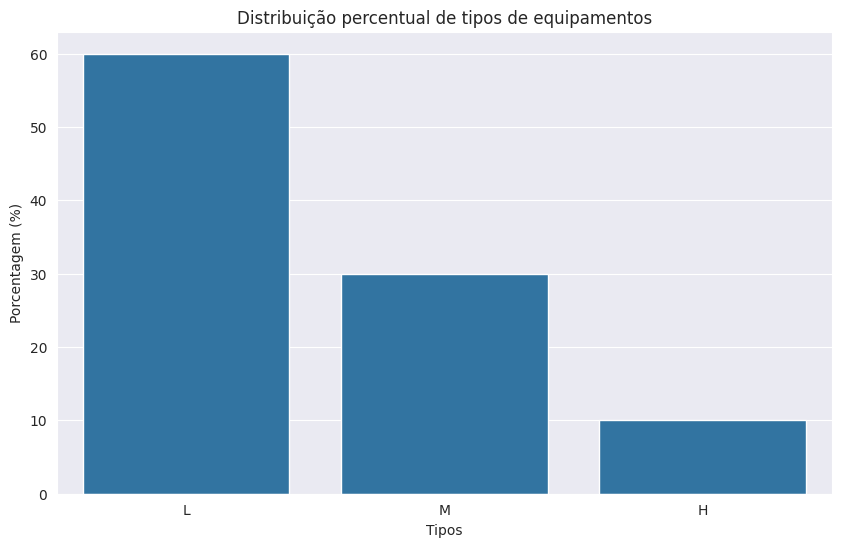

In [ ]:
plt.figure(figsize=(10,6))

percent = df['tipo'].value_counts(normalize=True) * 100

sns.barplot(x=percent.index, y=percent.values)

plt.ylabel("Porcentagem (%)")
plt.xlabel("Tipos")
plt.title("Distribuição percentual de tipos de equipamentos")

plt.show()



*   60% para categoria de equipamento L
*   30% para categoria de equipamento M
*   10% para categoria de equipamento L







## 1.4 Analise temperatura_ar_k

In [ ]:
def plot_hist_box(df, coluna, bins=30, kde=False, cor="steelblue", figsize=(10, 6)):
    fig, ax = plt.subplots(
        2, 1,
        figsize=figsize,
        gridspec_kw={"height_ratios": [1, 4]}
    )

    sns.boxplot(
        x=df[coluna],
        ax=ax[0],
        color=cor
    )
    ax[0].set_title(f"Boxplot - {coluna}")

    sns.histplot(
        df[coluna],
        bins=bins,
        kde=kde,
        ax=ax[1],
        color=cor
    )
    ax[1].set_title(f"Histograma - {coluna}")
    ax[1].set_xlabel(coluna)
    ax[1].set_ylabel("Frequência")

    plt.tight_layout()
    plt.show()

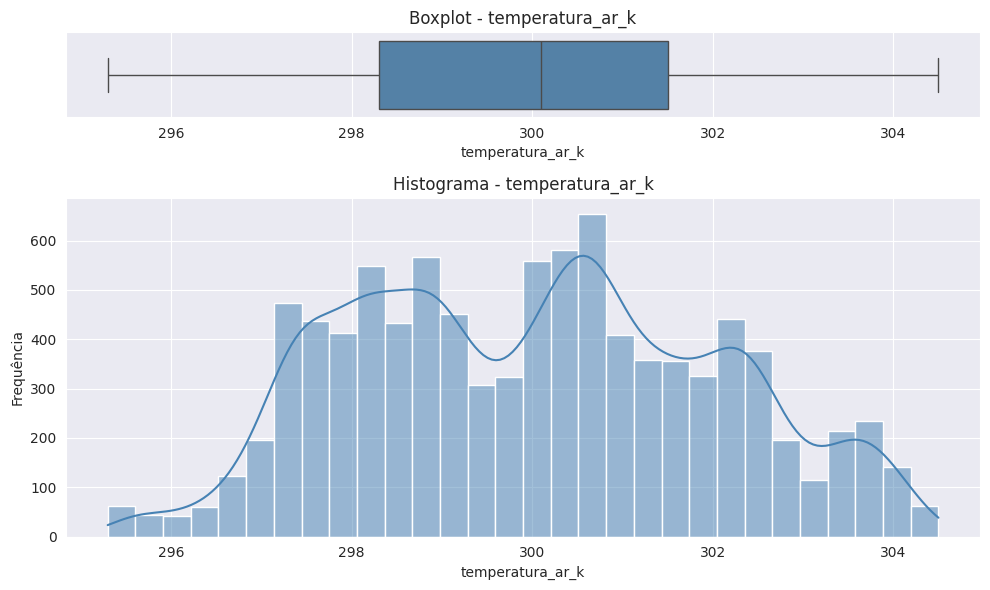

In [ ]:
plot_hist_box(df, "temperatura_ar_k", kde=True)



*   Boxplot indica que não há outilers com mediana em perto dos 300
*   No histograma vemos pico perto de 298, 300 e 302



## 1.5 Análise temperatura_processo_k

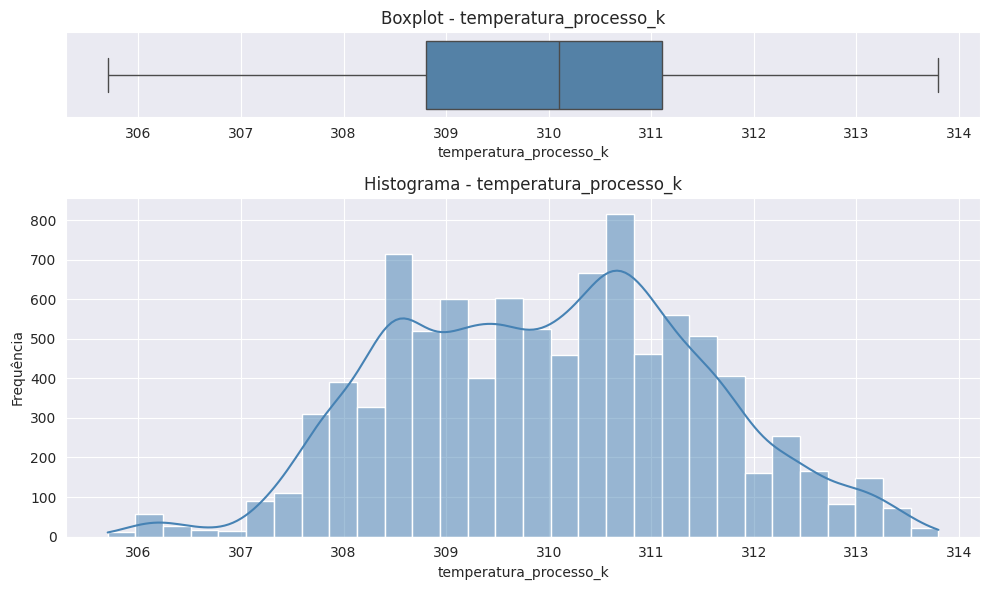

In [ ]:
plot_hist_box(df, "temperatura_processo_k", kde=True)



*   Boxplot indica que não há outilers com a mediana perto dos 310
*   No histograma vemos uma distribuição que náo é perfeitamente normal. A maior concentração est
a entre 308 a 311 com um pico entre 310 e 311





## 1.6 Análise velocidade_rotacao_rpm

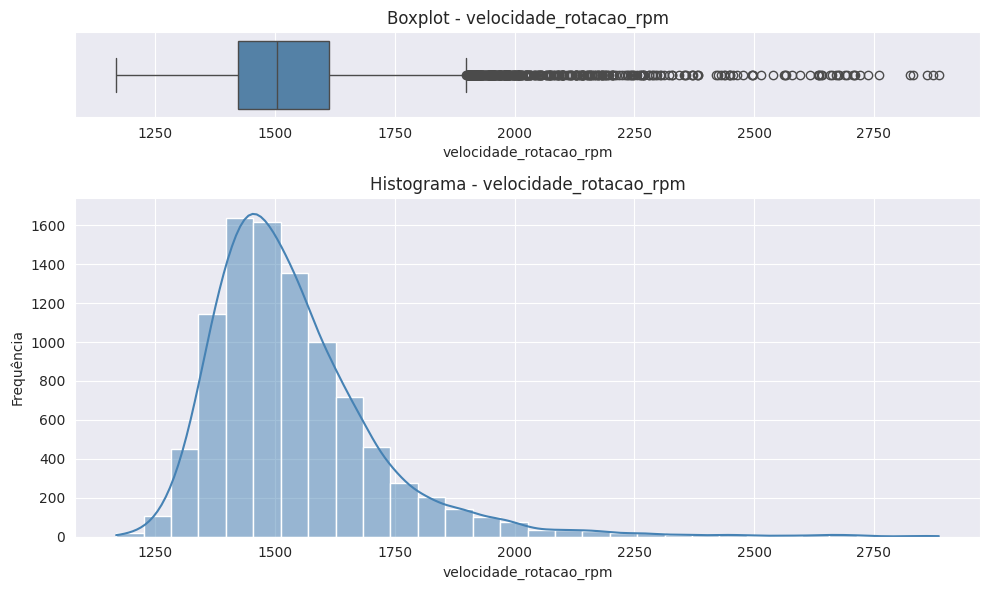

In [ ]:
plot_hist_box(df, "velocidade_rotacao_rpm", kde=True)


*   O boxplot indica a presença de diversos valores acima do limite superio, mediana esta perto dos 1500. Há bastante pontos acima do limite superior, pela quantidade de pontos não é outlier tradicional onde tem algumas observações, pela quantidade é como se comporta essa váriavel
*   O histograma apresenta uma distribuição assimétrica à direita (assimetria positiva), com a maior concentração de observações entre aproximadamente 1400 e 1600 rpm e uma cauda longa em direção aos maiores valores de rotação.

## 1.7 Análise torque_nm

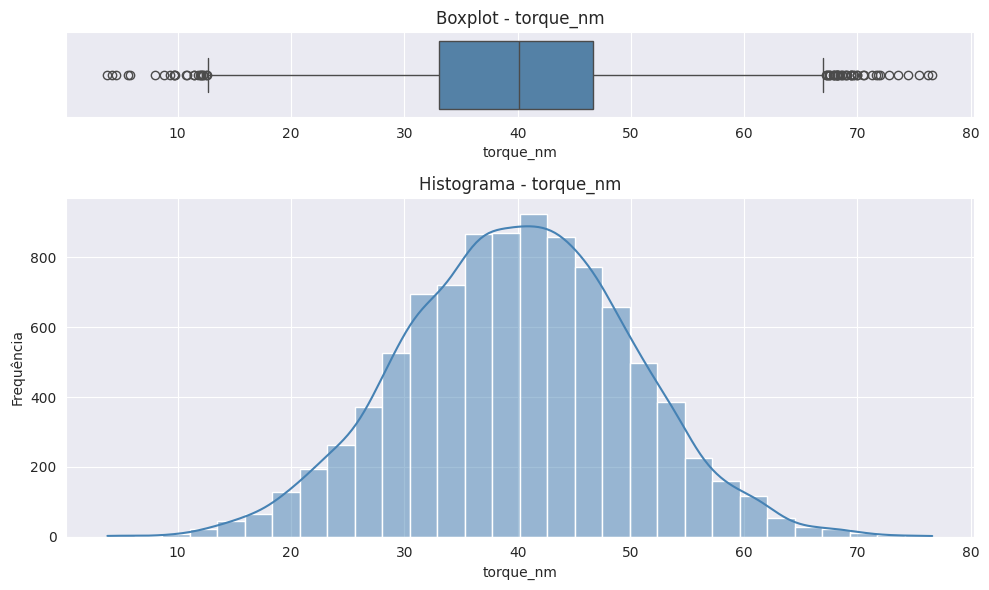

In [ ]:
plot_hist_box(df, "torque_nm", kde=True)


*   Boxplot indica de que a outliers dos dois lados. Mediana está em 40
*   No histograma vemos uma distribuição bem proxima a normal

## 1.8 Análise desgaste_ferramenta_min

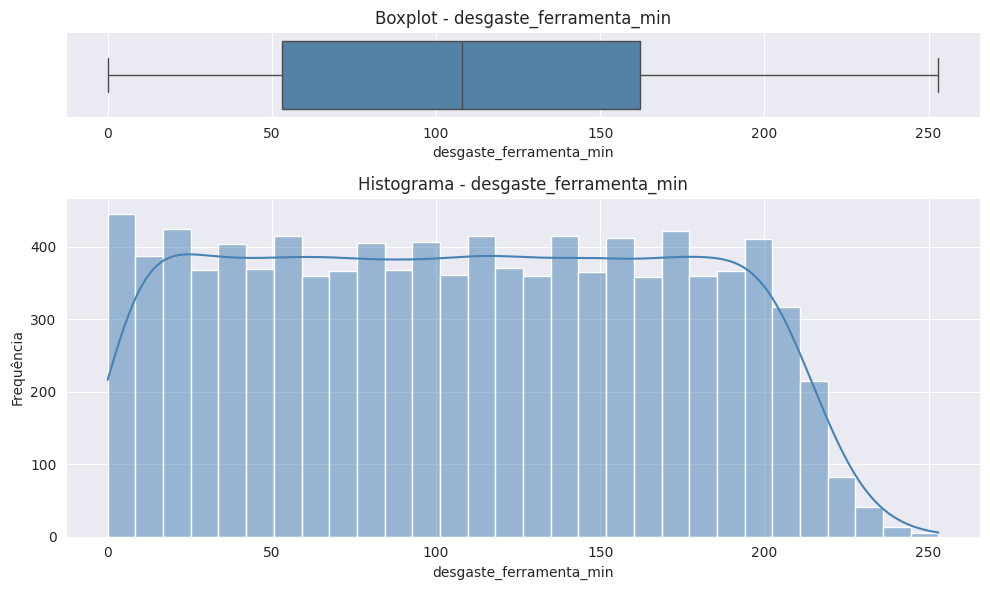

In [ ]:
plot_hist_box(df, "desgaste_ferramenta_min", kde=True)

*   Boxplot não indica outilers. A medina está próxima do 100. A caixa ocupa aproximadamente de 55 a 160 minutos, a variável posseu uma grande dispersão
*   No histograma de 0 a 200 minutos a váriavel é proxima de uma distribuição uniforme, após esse intervalo a uma queda

## 1.9 Correlação

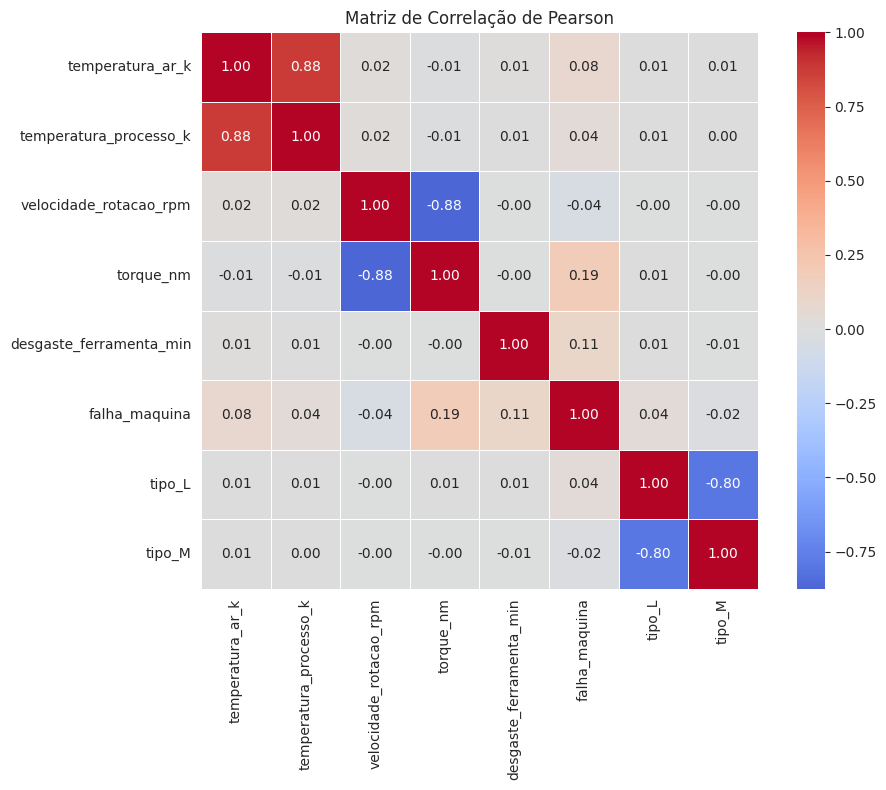

In [ ]:
variaveis = [
    "tipo",
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm",
    "desgaste_ferramenta_min",
    "falha_maquina"
]

# Converte a variável categórica em dummies
df_corr = pd.get_dummies(df[variaveis], columns=["tipo"], drop_first=True)

# Calcula a correlação no DataFrame transformado
corr = df_corr.corr(method="pearson")

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Matriz de Correlação de Pearson")
plt.tight_layout()
plt.show()



*   Temperatura do ar e Temperatura do processo fortemente correlacionadas,r = 0,88,
*   Velocidade de rotação e Torque correlação negativa forte, r = -0,80

*   Correlação com a variável-alvo: falha_maquina
    torque_nm = 0.19
    desgaste_ferramenta_min = 0,11
    temperatura_ar_k = 0,08
    temperatura_processo_k = 0,04
    velocidade_rotacao_rpm = -0,04
    tipo_l =0,04
    tipo_M = -0,02








## 1.10 Média e Mediana

In [ ]:
variaveis = [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm"
]

resultado = pd.DataFrame({
    "Média": df[variaveis].mean(),
    "Mediana": df[variaveis].median()
})

# Diferença absoluta
resultado["Diferença"] = resultado["Média"] - resultado["Mediana"]

# Diferença percentual em relação à mediana
resultado["Diferença (%)"] = (
    (resultado["Diferença"] / resultado["Mediana"]) * 100
)

# Arredonda para 2 casas decimais
resultado = resultado.round(2)

print(resultado)

                          Média  Mediana  Diferença  Diferença (%)
temperatura_ar_k         300.00    300.1      -0.10          -0.03
temperatura_processo_k   310.00    310.1      -0.10          -0.03
velocidade_rotacao_rpm  1539.25   1504.0      35.25           2.34
torque_nm                 39.97     40.1      -0.13          -0.31




1.   temperatura_ar_k e temperatura_processo_k tem a diferença mesma, -0,03%, praticamente a média é igual a mediana, então na imputação dos faltantes a média será utilizada

2.   torque_nm a diferença é de -0,31% média e mediana são parecidas, será utilizado a média na imputação de dados faltantes              

3.   velocidade_rotacao_rpm  a diferença já é consideravel 2,34% e o histograma mostra assimétria à direita, mediana é mais adequada para imputar nos dados faltantes







## 1.11 Dados duplicados

In [ ]:
# Quantidade de linhas duplicadas
duplicados = df.duplicated().sum()

print(f"Quantidade de linhas duplicadas: {duplicados}")

Quantidade de linhas duplicadas: 0


In [ ]:
df.duplicated(subset=["id_produto", "tipo"]).sum()

np.int64(0)



*   Náo a dados duplicados



# 2 Feature Engineering


In [26]:
df["potencia"] = (
    df["velocidade_rotacao_rpm"] *
    df["torque_nm"]
)

df["delta_temperatura"] = (
    df["temperatura_processo_k"] -
    df["temperatura_ar_k"]
)

df["desgaste_torque"] = (
    df["desgaste_ferramenta_min"] *
    df["torque_nm"]
)

df[["potencia", "desgaste_torque", "desgaste_torque"]]

,potencia,desgaste_torque,desgaste_torque
0,66382.8,0.0,0.0
1,65190.4,138.9,138.9
2,74001.2,247.0,247.0
3,NaN,NaN,NaN
4,56320.0,360.0,360.0
...,...,...,...
9995,47318.0,413.0,413.0
9996,51897.6,540.6,540.6
9997,54943.0,734.8,734.8
9998,68288.0,1212.5,1212.5




*   Potência: representa uma aproximação da potência mecânica, obtida pelo produto entre a velocidade de rotação RPM e o torque. Essa variável procura capturar o esforço mecânico aplicado durante a operação da máquina.

*   Delta de temperatura: representa a diferença entre a temperatura do processo e a temperatura do ambiente, indicando o aquecimento gerado durante a operação da máquina.


*   Desgaste × Torque: combina o tempo de desgaste da ferramenta com o torque aplicado. Ferramentas com maior tempo de utilização submetidas a elevados níveis de torque podem estar sujeitas a maiores esforços mecânicos, aumentando a probabilidade de falha do equipamento.

